## Experiment - 3
# Find S Algorithm
Read a dataset from the user.

1. Use the Find-S algorithm to find the most specific hypothesis consistent with the positive examples.

2.  State the final hypothesis after processing all positive examples.

In [8]:
data = {
  "attributes": ["Sky", "Temperature", "Humidity", "Wind"],
  "target": "Result",
  "positive_value": "Yes",

  "data": [
    ["Sunny", "Warm", "Normal", "Strong", "Yes"],
    ["Sunny", "Warm", "High", "Strong", "Yes"],
    ["Rainy", "Cold", "High", "Strong", "No"],
    ["Sunny", "Warm", "High", "Weak", "Yes"]
  ]
}

In [9]:
def find_s(config):
    attributes = config["attributes"]
    positive_value = config["positive_value"]
    data = config["data"]

    hypothesis = None
    history = []

    history.append({
        "step": "Initial",
        "hypothesis": ["Ø"] * len(attributes)
    })

    for i, row in enumerate(data, start=1):
        features = row[:-1]
        label = row[-1]

        if label == positive_value:

            if hypothesis is None:
                hypothesis = features.copy()

            else:
                for j in range(len(attributes)):
                    if hypothesis[j] != features[j]:
                        hypothesis[j] = "?"

            history.append({
                "step": f"Example {i}",
                "hypothesis": hypothesis.copy()
            })

        else:
            history.append({
                "step": f"Example {i} (Ignored)",
                "hypothesis": (
                    hypothesis.copy()
                    if hypothesis
                    else ["Ø"] * len(attributes)
                )
            })

    return history

In [10]:
import matplotlib.pyplot as plt

def plot_history(history, attributes):

    for item in history:

        hypothesis = item["hypothesis"]

        scores = []

        for value in hypothesis:
            if value == "Ø":
                scores.append(0)

            elif value == "?":
                scores.append(0.5)

            else:
                scores.append(1)

        plt.figure(figsize=(8, 5))

        bars = plt.bar(attributes, scores)

        plt.ylim(0, 1.2)

        plt.ylabel("Hypothesis Specificity")
        plt.title(
            f'{item["step"]}\n'
            f'H = <{", ".join(hypothesis)}>'
        )

        # Put actual hypothesis value above each bar
        for bar, value in zip(bars, hypothesis):
            plt.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05,
                value,
                ha="center",
                fontsize=11
            )

        plt.show()

In [14]:
history = find_s(data)

print("Final Hypothesis",history[-1]["hypothesis"])

Final Hypothesis ['Sunny', 'Warm', '?', '?']


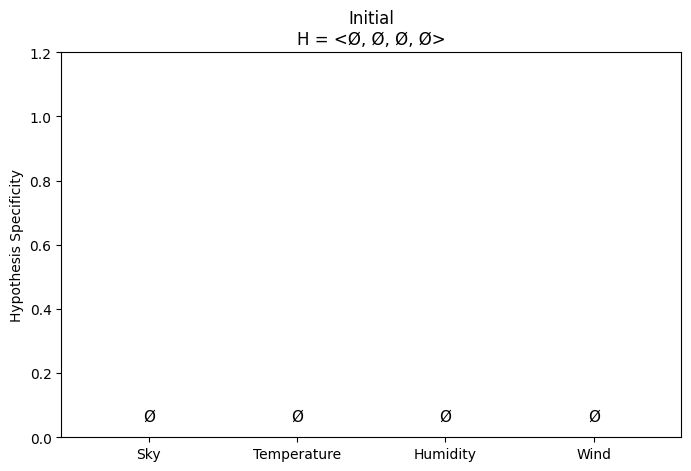

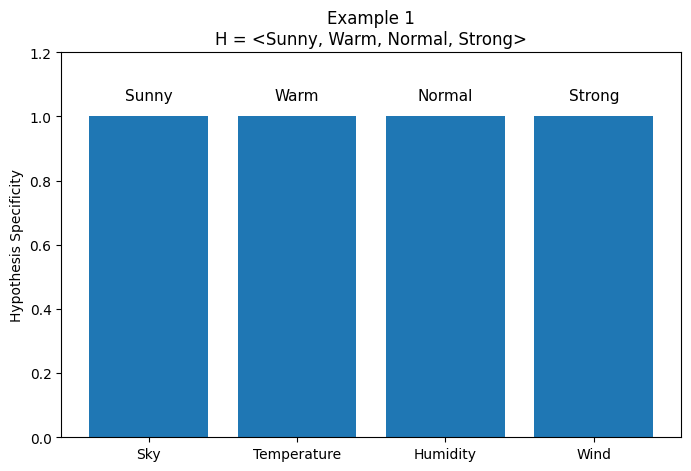

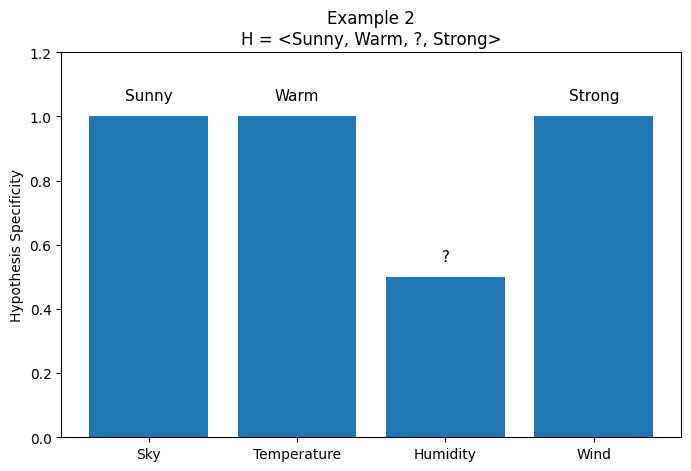

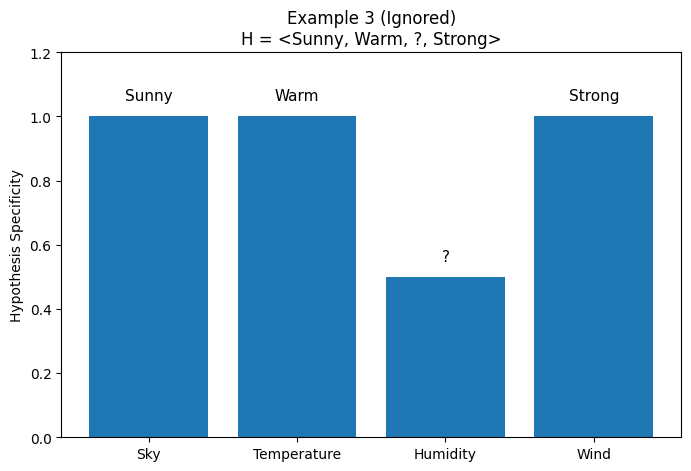

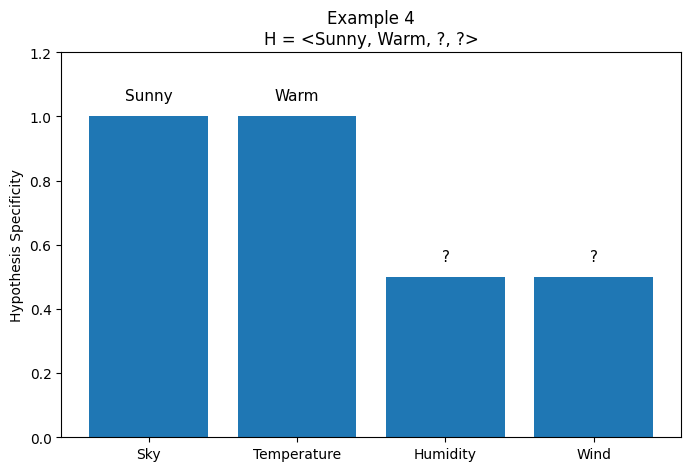

In [15]:
plot_history(
    history,
    data["attributes"]
)